# Model Optimization and Training

This notebook contains comprehensive training and optimization of four different model types:
1. **Penalized Linear Model** (Ridge/Lasso/ElasticNet with Logistic Regression)
2. **Support Vector Machine (SVM)**
3. **Ensemble Model** (Gradient Boosting)
4. **Neural Network** (PyTorch)

**IMPORTANT**: All training and hyperparameter tuning is performed using cross-validation on the training data only. The test set is NOT used during optimization.

## Notebook Structure
- Data Loading and Preparation
- Preprocessing Pipeline Setup
- Model 1: Penalized Logistic Regression with Cross-Validation
- Model 2: Support Vector Machine with Cross-Validation
- Model 3: Gradient Boosting Ensemble with Cross-Validation
- Model 4: PyTorch Neural Network with Cross-Validation
- Model Comparison and Selection

## 1. Import Required Libraries

In [5]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Data preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Model selection and evaluation
from sklearn.model_selection import cross_validate, GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from sklearn.metrics import classification_report

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load and Explore the Data

In [6]:
# Load the dataset
df = pd.read_csv('../Data/full_dataset.csv', sep=';')

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())

print(f"\nData types:")
print(df.dtypes)

print(f"\nTarget variable distribution:")
print(df['y'].value_counts())
print(f"\nTarget proportions:")
print(df['y'].value_counts(normalize=True))

Dataset shape: (41188, 21)

First few rows:
   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.pric

## 3. Data Preprocessing and Train-Test Split

We perform the train-test split FIRST to ensure the test set remains untouched during optimization.

In [7]:
# Separate features and target
X = df.drop('y', axis=1)
y = df['y']

# Convert target to binary (yes=1, no=0)
y = (y == 'yes').astype(int)

# Split into training (80%) and test (20%)
# This test set will NOT be used until the final evaluation notebook
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTraining set target distribution:")
print(pd.Series(y_train).value_counts())
print(f"\nTest set target distribution:")
print(pd.Series(y_test).value_counts())

Training set size: 32950
Test set size: 8238

Training set target distribution:
y
0    29238
1     3712
Name: count, dtype: int64

Test set target distribution:
y
0    7310
1     928
Name: count, dtype: int64


## 4. Identify Feature Types

In [8]:
# Identify categorical and numerical features
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"\nNumerical features ({len(numerical_features)}): {numerical_features}")

Categorical features (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

Numerical features (10): ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


## 5. Create Preprocessing Pipeline

The preprocessing is embedded in the pipeline to avoid data leakage during cross-validation.

In [9]:
# Define preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

print("Preprocessing pipeline created with:")
print(f"  - StandardScaler for numerical features: {numerical_features}")
print(f"  - OneHotEncoder for categorical features: {categorical_features}")

Preprocessing pipeline created with:
  - StandardScaler for numerical features: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
  - OneHotEncoder for categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


## 6. MODEL 1: Penalized Logistic Regression

We'll optimize the type of regularization (L1, L2, or ElasticNet) and the regularization strength (C parameter).

In [10]:
print("="*70)
print("MODEL 1: PENALIZED LOGISTIC REGRESSION")
print("="*70)

# Create pipeline for Logistic Regression
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42, solver='saga'))
])

# Hyperparameter grid
lr_param_grid = {
    'classifier__penalty': ['l1', 'l2', 'elasticnet'],
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
}

# Note: elasticnet requires l1_ratio parameter
# We'll modify the grid to handle this
lr_param_grid = [
    {
        'classifier__penalty': ['l1', 'l2'],
        'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100]
    },
    {
        'classifier__penalty': ['elasticnet'],
        'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'classifier__l1_ratio': [0.3, 0.5, 0.7]
    }
]

# Cross-validation setup
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid search with cross-validation
print("\nPerforming GridSearchCV for Logistic Regression...")
lr_grid_search = GridSearchCV(
    lr_pipeline,
    lr_param_grid,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

lr_grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {lr_grid_search.best_params_}")
print(f"Best cross-validation ROC-AUC score: {lr_grid_search.best_score_:.4f}")

MODEL 1: PENALIZED LOGISTIC REGRESSION

Performing GridSearchCV for Logistic Regression...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best parameters: {'classifier__C': 1, 'classifier__penalty': 'l1'}
Best cross-validation ROC-AUC score: 0.9331


### Logistic Regression Results Summary

In [11]:
# Get cross-validation predictions for Logistic Regression
lr_best_model = lr_grid_search.best_estimator_

# Perform cross-validation with multiple metrics
lr_scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

lr_cv_results = cross_validate(
    lr_best_model,
    X_train,
    y_train,
    cv=cv_strategy,
    scoring=lr_scoring,
    return_train_score=True
)

# Print results
print("\nLogistic Regression - Cross-Validation Performance:")
print(f"  Accuracy:  {lr_cv_results['test_accuracy'].mean():.4f} (+/- {lr_cv_results['test_accuracy'].std():.4f})")
print(f"  Precision: {lr_cv_results['test_precision'].mean():.4f} (+/- {lr_cv_results['test_precision'].std():.4f})")
print(f"  Recall:    {lr_cv_results['test_recall'].mean():.4f} (+/- {lr_cv_results['test_recall'].std():.4f})")
print(f"  F1-Score:  {lr_cv_results['test_f1'].mean():.4f} (+/- {lr_cv_results['test_f1'].std():.4f})")
print(f"  ROC-AUC:   {lr_cv_results['test_roc_auc'].mean():.4f} (+/- {lr_cv_results['test_roc_auc'].std():.4f})")

# Store best model info
lr_best_score = lr_grid_search.best_score_


Logistic Regression - Cross-Validation Performance:
  Accuracy:  0.9096 (+/- 0.0022)
  Precision: 0.6563 (+/- 0.0180)
  Recall:    0.4151 (+/- 0.0086)
  F1-Score:  0.5085 (+/- 0.0102)
  ROC-AUC:   0.9331 (+/- 0.0040)


## 7. MODEL 2: Support Vector Machine (SVM)

We'll optimize the kernel type, regularization parameter (C), and kernel-specific parameters.

In [30]:
from sklearn.model_selection import cross_val_score

print("\n" + "="*70)
print("MODEL 2: SUPPORT VECTOR MACHINE (SVM)")
print("="*70)

# ===========================================================================
# ULTRA-MINIMAL SVM SEARCH - 3-5 minutes total
# Test only 3 key configurations with 3-fold CV
# ===========================================================================

from sklearn.model_selection import StratifiedKFold

# Use 3-fold CV for speed (instead of 5-fold)
cv_fast = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Just test 3 carefully chosen configurations
# These are industry-standard starting points that work well in practice
configs = [
    {'kernel': 'linear', 'C': 1},      # Fast baseline - good for many problems
    {'kernel': 'rbf', 'C': 10, 'gamma': 'scale'},   # Most common RBF config
    {'kernel': 'rbf', 'C': 100, 'gamma': 'scale'},  # Higher regularization
]

best_score = -np.inf
best_config = None
svm_results = []

print("Testing 3 carefully chosen SVM configurations...")
print("(Using 3-fold CV for speed)\n")

for i, config in enumerate(configs, 1):
    print(f"[{i}/3] Testing: {config}")
    
    svm_pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', SVC(**config, random_state=42, probability=True))
    ])
    
    # Cross-validation
    scores = cross_val_score(
        svm_pipe, X_train, y_train,
        cv=cv_fast,  # Using 3-fold instead of 5-fold
        scoring='roc_auc', 
        n_jobs=-1
    )
    
    mean_score = scores.mean()
    std_score = scores.std()
    
    svm_results.append({
        **config,
        'mean_roc_auc': mean_score,
        'std_roc_auc': std_score
    })
    
    print(f"      ROC-AUC: {mean_score:.4f} (+/- {std_score:.4f})\n")
    
    if mean_score > best_score:
        best_score = mean_score
        best_config = config

print("="*70)
print(f"✓ Best SVM Configuration: {best_config}")
print(f"✓ Best cross-validation ROC-AUC: {best_score:.4f}")
print("="*70)

# Train final model with best config on full training data
print("\nTraining final SVM model with best parameters...")
svm_best_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(**best_config, random_state=42, probability=True))
])
svm_best_model.fit(X_train, y_train)
svm_cv_score = best_score

# Create results DataFrame for reporting
svm_results_df = pd.DataFrame(svm_results)
print("\nAll SVM Results:")
print(svm_results_df.to_string(index=False))


MODEL 2: SUPPORT VECTOR MACHINE (SVM)
Testing 3 carefully chosen SVM configurations...
(Using 3-fold CV for speed)

[1/3] Testing: {'kernel': 'linear', 'C': 1}
      ROC-AUC: 0.9308 (+/- 0.0024)

[2/3] Testing: {'kernel': 'rbf', 'C': 10, 'gamma': 'scale'}
      ROC-AUC: 0.9159 (+/- 0.0028)

[3/3] Testing: {'kernel': 'rbf', 'C': 100, 'gamma': 'scale'}
      ROC-AUC: 0.9024 (+/- 0.0033)

✓ Best SVM Configuration: {'kernel': 'linear', 'C': 1}
✓ Best cross-validation ROC-AUC: 0.9308

Training final SVM model with best parameters...

All SVM Results:
kernel   C  mean_roc_auc  std_roc_auc gamma
linear   1      0.930813     0.002430   NaN
   rbf  10      0.915893     0.002839 scale
   rbf 100      0.902380     0.003314 scale


### SVM Results Summary

In [34]:
# ============================================================================
# SVM MODEL EVALUATION - Multiple Metrics
# ============================================================================

from sklearn.model_selection import cross_validate

print("\n" + "="*70)
print("SVM MODEL - DETAILED CROSS-VALIDATION PERFORMANCE")
print("="*70)

# Use the best model we already identified and trained
# (svm_best_model and svm_cv_score are already defined from previous section)

# Define multiple scoring metrics
svm_scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

# Perform comprehensive cross-validation with multiple metrics
# Using the same CV strategy for consistency
svm_cv_results = cross_validate(
    svm_best_model,
    X_train,
    y_train,
    cv=cv_fast,  # Using 3-fold CV for consistency with hyperparameter search
    scoring=svm_scoring,
    return_train_score=True,
    n_jobs=-1
)

# Calculate means and standard deviations
svm_metrics = {
    'Accuracy': (svm_cv_results['test_accuracy'].mean(), 
                 svm_cv_results['test_accuracy'].std()),
    'Precision': (svm_cv_results['test_precision'].mean(), 
                  svm_cv_results['test_precision'].std()),
    'Recall': (svm_cv_results['test_recall'].mean(), 
               svm_cv_results['test_recall'].std()),
    'F1-Score': (svm_cv_results['test_f1'].mean(), 
                 svm_cv_results['test_f1'].std()),
    'ROC-AUC': (svm_cv_results['test_roc_auc'].mean(), 
                svm_cv_results['test_roc_auc'].std())
}

# Print results in a clean format
print("\nSVM - Cross-Validation Performance:")
print("-" * 70)
for metric, (mean, std) in svm_metrics.items():
    print(f"  {metric:<12} {mean:.4f} (+/- {std:.4f})")
print("-" * 70)

# Print best configuration reminder
print(f"\nBest Configuration: {best_config}")
print(f"Primary Metric (ROC-AUC): {svm_cv_score:.4f}")

# Store for later comparison
svm_best_score = svm_cv_score

# Create a DataFrame for easy comparison later
svm_performance_df = pd.DataFrame({
    'Metric': list(svm_metrics.keys()),
    'Mean': [m[0] for m in svm_metrics.values()],
    'Std': [m[1] for m in svm_metrics.values()]
})

print("\nSVM Performance Summary Table:")
print(svm_performance_df.to_string(index=False))


SVM MODEL - DETAILED CROSS-VALIDATION PERFORMANCE

SVM - Cross-Validation Performance:
----------------------------------------------------------------------
  Accuracy     0.9033 (+/- 0.0022)
  Precision    0.6484 (+/- 0.0175)
  Recall       0.3095 (+/- 0.0159)
  F1-Score     0.4190 (+/- 0.0181)
  ROC-AUC      0.9308 (+/- 0.0024)
----------------------------------------------------------------------

Best Configuration: {'kernel': 'linear', 'C': 1}
Primary Metric (ROC-AUC): 0.9308

SVM Performance Summary Table:
   Metric     Mean      Std
 Accuracy 0.903338 0.002247
Precision 0.648395 0.017508
   Recall 0.309531 0.015934
 F1-Score 0.418963 0.018111
  ROC-AUC 0.930813 0.002430


## 8. MODEL 3: Gradient Boosting Ensemble

We'll optimize the number of estimators, learning rate, and tree depth.

In [15]:
print("\n" + "="*70)
print("MODEL 3: GRADIENT BOOSTING ENSEMBLE")
print("="*70)

# Create pipeline for Gradient Boosting
gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

# Hyperparameter grid for Gradient Boosting
gb_param_grid = {
    'classifier__n_estimators': [50, 100, 150],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__max_depth': [3, 4, 5],
    'classifier__min_samples_split': [5, 10],
    'classifier__min_samples_leaf': [2, 4]
}

# Grid search with cross-validation
print("\nPerforming GridSearchCV for Gradient Boosting...")
print("(This may take several minutes)")

gb_grid_search = GridSearchCV(
    gb_pipeline,
    gb_param_grid,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

gb_grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {gb_grid_search.best_params_}")
print(f"Best cross-validation ROC-AUC score: {gb_grid_search.best_score_:.4f}")


MODEL 3: GRADIENT BOOSTING ENSEMBLE

Performing GridSearchCV for Gradient Boosting...
(This may take several minutes)
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best parameters: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 100}
Best cross-validation ROC-AUC score: 0.9470


### Gradient Boosting Results Summary

In [16]:
# Get cross-validation predictions for Gradient Boosting
gb_best_model = gb_grid_search.best_estimator_

# Perform cross-validation with multiple metrics
gb_cv_results = cross_validate(
    gb_best_model,
    X_train,
    y_train,
    cv=cv_strategy,
    scoring=lr_scoring,
    return_train_score=True
)

# Print results
print("\nGradient Boosting - Cross-Validation Performance:")
print(f"  Accuracy:  {gb_cv_results['test_accuracy'].mean():.4f} (+/- {gb_cv_results['test_accuracy'].std():.4f})")
print(f"  Precision: {gb_cv_results['test_precision'].mean():.4f} (+/- {gb_cv_results['test_precision'].std():.4f})")
print(f"  Recall:    {gb_cv_results['test_recall'].mean():.4f} (+/- {gb_cv_results['test_recall'].std():.4f})")
print(f"  F1-Score:  {gb_cv_results['test_f1'].mean():.4f} (+/- {gb_cv_results['test_f1'].std():.4f})")
print(f"  ROC-AUC:   {gb_cv_results['test_roc_auc'].mean():.4f} (+/- {gb_cv_results['test_roc_auc'].std():.4f})")

# Store best model info
gb_best_score = gb_grid_search.best_score_


Gradient Boosting - Cross-Validation Performance:
  Accuracy:  0.9157 (+/- 0.0024)
  Precision: 0.6527 (+/- 0.0183)
  Recall:    0.5401 (+/- 0.0112)
  F1-Score:  0.5909 (+/- 0.0075)
  ROC-AUC:   0.9470 (+/- 0.0031)


## 9. MODEL 4: PyTorch Neural Network

We'll create and optimize a neural network with different architectures and hyperparameters.

In [17]:
print("\n" + "="*70)
print("MODEL 4: PYTORCH NEURAL NETWORK")
print("="*70)

# First, we need to preprocess the data for PyTorch
# Fit the preprocessor on training data
preprocessor_fit = preprocessor.fit(X_train, y_train)
X_train_processed = preprocessor_fit.transform(X_train)

print(f"\nProcessed feature shape: {X_train_processed.shape}")
input_dim = X_train_processed.shape[1]
print(f"Input dimension: {input_dim}")


MODEL 4: PYTORCH NEURAL NETWORK

Processed feature shape: (32950, 63)
Input dimension: 63


In [18]:
# Define the neural network architecture
class NeuralNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim1, hidden_dim2, dropout_rate=0.3):
        super(NeuralNetwork, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim1)
        self.dropout1 = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden_dim1, hidden_dim2)
        self.dropout2 = nn.Dropout(dropout_rate)
        self.fc3 = nn.Linear(hidden_dim2, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout1(x)
        x = self.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.sigmoid(self.fc3(x))
        return x

print("Neural Network class defined.")

Neural Network class defined.


In [19]:
# Function to train the neural network with cross-validation
def train_neural_network(X_train_processed, y_train_array, hidden_dim1, hidden_dim2, 
                         dropout_rate, learning_rate, batch_size, epochs):
    """
    Train a neural network with k-fold cross-validation.
    Returns mean and std of ROC-AUC scores across folds.
    """
    cv_scores = []
    
    # Use StratifiedKFold for consistent fold creation
    for fold, (train_idx, val_idx) in enumerate(cv_strategy.split(X_train_processed, y_train_array)):
        # Reset seed for each fold
        torch.manual_seed(42 + fold)  # Different seed for each fold
        np.random.seed(42 + fold)
        
        # Split data for this fold
        X_fold_train = X_train_processed[train_idx]
        y_fold_train = y_train_array[train_idx]
        X_fold_val = X_train_processed[val_idx]
        y_fold_val = y_train_array[val_idx]
        
        # Convert to PyTorch tensors
        X_fold_train_tensor = torch.FloatTensor(X_fold_train)
        y_fold_train_tensor = torch.FloatTensor(y_fold_train).reshape(-1, 1)
        X_fold_val_tensor = torch.FloatTensor(X_fold_val)
        y_fold_val_tensor = torch.FloatTensor(y_fold_val).reshape(-1, 1)
        
        # Create data loader
        train_dataset = TensorDataset(X_fold_train_tensor, y_fold_train_tensor)
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        
        # Initialize model
        model = NeuralNetwork(input_dim, hidden_dim1, hidden_dim2, dropout_rate)
        criterion = nn.BCELoss()
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
        
        # Training loop
        for epoch in range(epochs):
            model.train()
            for X_batch, y_batch in train_loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
        
        # Validation
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_fold_val_tensor).numpy()
            val_score = roc_auc_score(y_fold_val, val_outputs)
            cv_scores.append(val_score)
    
    return np.mean(cv_scores), np.std(cv_scores), cv_scores

print("Training function defined.")

Training function defined.


In [21]:
# STRATEGY 1: COARSE-TO-FINE SEARCH
# First do a quick coarse search, then fine-tune around the best parameters

import numpy as np
from sklearn.model_selection import KFold

# Convert y_train to numpy for PyTorch
y_train_array = y_train.values

print("="*80)
print("PHASE 1: COARSE SEARCH (Fast exploration)")
print("="*80)

# Coarse search with FEWER combinations and FEWER epochs
coarse_params = {
    'hidden_dim1': [64, 128],
    'hidden_dim2': [32, 64], 
    'dropout_rate': [0.3],  # Just test middle value
    'learning_rate': [0.001, 0.01],  # Test extremes only
    'batch_size': [64]  # Use larger batch = faster
}

best_coarse_score = -np.inf
best_coarse_params = None

# Only ~8 combinations instead of 288!
for hidden_dim1 in coarse_params['hidden_dim1']:
    for hidden_dim2 in coarse_params['hidden_dim2']:
        for lr in coarse_params['learning_rate']:
            
            mean_score, std_score, fold_scores = train_neural_network(
                X_train_processed, y_train_array,
                hidden_dim1=hidden_dim1,
                hidden_dim2=hidden_dim2,
                dropout_rate=0.3,
                learning_rate=lr,
                batch_size=64,
                epochs=30  # REDUCED from 50
            )
            
            if mean_score > best_coarse_score:
                best_coarse_score = mean_score
                best_coarse_params = {
                    'hidden_dim1': hidden_dim1,
                    'hidden_dim2': hidden_dim2,
                    'learning_rate': lr
                }
            
            print(f"Hidden: {hidden_dim1}-{hidden_dim2}, LR: {lr} | "
                  f"ROC-AUC: {mean_score:.4f} (+/- {std_score:.4f})")

print(f"\nBest from coarse search: {best_coarse_params}")
print(f"Score: {best_coarse_score:.4f}")

print("\n" + "="*80)
print("PHASE 2: FINE-TUNING (Refine around best parameters)")
print("="*80)

# Now fine-tune around the best architecture
fine_params = {
    'dropout_rate': [0.2, 0.3, 0.4],
    'learning_rate': [best_coarse_params['learning_rate'] * 0.5, 
                     best_coarse_params['learning_rate'],
                     best_coarse_params['learning_rate'] * 2],
    'batch_size': [32, 64]
}

best_nn_score = -np.inf
best_nn_params = None
nn_results = []

# Only ~18 combinations to test
for dropout_rate in fine_params['dropout_rate']:
    for lr in fine_params['learning_rate']:
        for batch_size in fine_params['batch_size']:
            
            mean_score, std_score, fold_scores = train_neural_network(
                X_train_processed, y_train_array,
                hidden_dim1=best_coarse_params['hidden_dim1'],
                hidden_dim2=best_coarse_params['hidden_dim2'],
                dropout_rate=dropout_rate,
                learning_rate=lr,
                batch_size=batch_size,
                epochs=50  # Full epochs for fine-tuning
            )
            
            nn_results.append({
                'hidden_dim1': best_coarse_params['hidden_dim1'],
                'hidden_dim2': best_coarse_params['hidden_dim2'],
                'dropout_rate': dropout_rate,
                'learning_rate': lr,
                'batch_size': batch_size,
                'mean_roc_auc': mean_score,
                'std_roc_auc': std_score
            })
            
            if mean_score > best_nn_score:
                best_nn_score = mean_score
                best_nn_params = {
                    'hidden_dim1': best_coarse_params['hidden_dim1'],
                    'hidden_dim2': best_coarse_params['hidden_dim2'],
                    'dropout_rate': dropout_rate,
                    'learning_rate': lr,
                    'batch_size': batch_size
                }
            
            print(f"Dropout: {dropout_rate}, LR: {lr:.4f}, Batch: {batch_size} | "
                  f"ROC-AUC: {mean_score:.4f} (+/- {std_score:.4f})")

print(f"\n{'='*80}")
print(f"FINAL Best Neural Network Parameters: {best_nn_params}")
print(f"Best cross-validation ROC-AUC score: {best_nn_score:.4f}")
print(f"{'='*80}")

# Create results DataFrame
nn_results_df = pd.DataFrame(nn_results)
nn_results_df = nn_results_df.sort_values('mean_roc_auc', ascending=False)
print("\nTop 5 configurations:")
print(nn_results_df.head())

PHASE 1: COARSE SEARCH (Fast exploration)
Hidden: 64-32, LR: 0.001 | ROC-AUC: 0.9385 (+/- 0.0041)
Hidden: 64-32, LR: 0.01 | ROC-AUC: 0.9355 (+/- 0.0026)
Hidden: 64-64, LR: 0.001 | ROC-AUC: 0.9392 (+/- 0.0024)
Hidden: 64-64, LR: 0.01 | ROC-AUC: 0.9363 (+/- 0.0058)
Hidden: 128-32, LR: 0.001 | ROC-AUC: 0.9379 (+/- 0.0038)
Hidden: 128-32, LR: 0.01 | ROC-AUC: 0.9339 (+/- 0.0037)
Hidden: 128-64, LR: 0.001 | ROC-AUC: 0.9375 (+/- 0.0038)
Hidden: 128-64, LR: 0.01 | ROC-AUC: 0.9343 (+/- 0.0026)

Best from coarse search: {'hidden_dim1': 64, 'hidden_dim2': 64, 'learning_rate': 0.001}
Score: 0.9392

PHASE 2: FINE-TUNING (Refine around best parameters)
Dropout: 0.2, LR: 0.0005, Batch: 32 | ROC-AUC: 0.9365 (+/- 0.0030)
Dropout: 0.2, LR: 0.0005, Batch: 64 | ROC-AUC: 0.9387 (+/- 0.0034)
Dropout: 0.2, LR: 0.0010, Batch: 32 | ROC-AUC: 0.9322 (+/- 0.0036)
Dropout: 0.2, LR: 0.0010, Batch: 64 | ROC-AUC: 0.9348 (+/- 0.0028)
Dropout: 0.2, LR: 0.0020, Batch: 32 | ROC-AUC: 0.9305 (+/- 0.0037)
Dropout: 0.2, LR: 

### Neural Network Results Summary

In [24]:
# Train the best neural network model for final evaluation
torch.manual_seed(42)
np.random.seed(42)

best_nn_model = NeuralNetwork(
    input_dim, 
    best_nn_params['hidden_dim1'],
    best_nn_params['hidden_dim2'],
    best_nn_params['dropout_rate']
)

# Convert entire training set to tensor
X_train_tensor = torch.FloatTensor(X_train_processed)
y_train_tensor = torch.FloatTensor(y_train_array).reshape(-1, 1)

# Train on full training set
criterion = nn.BCELoss()
optimizer = optim.Adam(best_nn_model.parameters(), lr=best_nn_params['learning_rate'])
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=best_nn_params['batch_size'], shuffle=True)

print("Training best neural network model on full training set...")
for epoch in range(100):
    best_nn_model.train()
    for X_batch, y_batch in train_loader:
        outputs = best_nn_model(X_batch)
        loss = criterion(outputs, y_batch)
        optimizer.zero_grad()
loss.backward()
optimizer.step()

print("\nNeural Network - Best Model Trained")
print(f"  Cross-validation ROC-AUC: {best_nn_score:.4f}")

Training best neural network model on full training set...

Neural Network - Best Model Trained
  Cross-validation ROC-AUC: 0.9396


## 10. Model Comparison and Selection

In [35]:
# ============================================================================
# MODEL COMPARISON
# ============================================================================

# For SVM, we need to get the cv_results since we only stored the best score
# Re-run cross_validate to get all metrics for comparison
if 'svm_cv_results' not in locals():
    print("Getting detailed SVM metrics for comparison...")
    svm_scoring = {
        'accuracy': 'accuracy',
        'precision': 'precision',
        'recall': 'recall',
        'f1': 'f1',
        'roc_auc': 'roc_auc'
    }
    
    svm_cv_results = cross_validate(
        svm_best_model,
        X_train,
        y_train,
        cv=cv_fast,
        scoring=svm_scoring,
        n_jobs=-1
    )

# Create comparison dataframe
model_comparison = pd.DataFrame({
    'Model': [
        'Penalized Logistic Regression',
        'Support Vector Machine',
        'Gradient Boosting',
        'Neural Network'
    ],
    'Cross-Val ROC-AUC': [
        lr_cv_results['test_roc_auc'].mean(),
        svm_cv_results['test_roc_auc'].mean(),
        gb_cv_results['test_roc_auc'].mean(),
        best_nn_score
    ],
    'STD (ROC-AUC)': [
        lr_cv_results['test_roc_auc'].std(),
        svm_cv_results['test_roc_auc'].std(),
        gb_cv_results['test_roc_auc'].std(),
        # Find the std for best NN config from results
        next(r['std_roc_auc'] for r in nn_results 
             if r['mean_roc_auc'] == best_nn_score)
    ],
    'Accuracy': [
        lr_cv_results['test_accuracy'].mean(),
        svm_cv_results['test_accuracy'].mean(),
        gb_cv_results['test_accuracy'].mean(),
        'N/A'
    ],
    'F1-Score': [
        lr_cv_results['test_f1'].mean(),
        svm_cv_results['test_f1'].mean(),
        gb_cv_results['test_f1'].mean(),
        'N/A'
    ]
})

# Sort by ROC-AUC (descending)
model_comparison = model_comparison.sort_values('Cross-Val ROC-AUC', ascending=False).reset_index(drop=True)

print("\n" + "="*70)
print("MODEL COMPARISON (Based on Cross-Validation)")
print("="*70)
print(model_comparison.to_string(index=False))

# Identify best model
best_model_idx = model_comparison['Cross-Val ROC-AUC'].idxmax()
best_model_name = model_comparison.iloc[best_model_idx]['Model']
best_model_score = model_comparison.iloc[best_model_idx]['Cross-Val ROC-AUC']

print(f"\n\n{'='*70}")
print(f"BEST MODEL: {best_model_name}")
print(f"Cross-Validation ROC-AUC: {best_model_score:.4f}")
print(f"{'='*70}")

# Show ranking
print("\nModel Ranking (by ROC-AUC):")
for i, row in model_comparison.iterrows():
    print(f"  {i+1}. {row['Model']}: {row['Cross-Val ROC-AUC']:.4f} (+/- {row['STD (ROC-AUC)']:.4f})")

# Additional comparison metrics
print("\n" + "="*70)
print("DETAILED METRIC COMPARISON")
print("="*70)

# Create a more detailed comparison with all metrics
detailed_comparison = pd.DataFrame({
    'Model': model_comparison['Model'],
    'ROC-AUC': model_comparison['Cross-Val ROC-AUC'],
    'Accuracy': model_comparison['Accuracy'],
    'F1-Score': model_comparison['F1-Score']
})

print(detailed_comparison.to_string(index=False))


MODEL COMPARISON (Based on Cross-Validation)
                        Model  Cross-Val ROC-AUC  STD (ROC-AUC)  Accuracy  F1-Score
            Gradient Boosting           0.946964       0.003086  0.915721  0.590862
               Neural Network           0.939570       0.003064       N/A       N/A
Penalized Logistic Regression           0.933116       0.004036   0.90959  0.508515
       Support Vector Machine           0.930813       0.002430  0.903338  0.418963


BEST MODEL: Gradient Boosting
Cross-Validation ROC-AUC: 0.9470

Model Ranking (by ROC-AUC):
  1. Gradient Boosting: 0.9470 (+/- 0.0031)
  2. Neural Network: 0.9396 (+/- 0.0031)
  3. Penalized Logistic Regression: 0.9331 (+/- 0.0040)
  4. Support Vector Machine: 0.9308 (+/- 0.0024)

DETAILED METRIC COMPARISON
                        Model  ROC-AUC  Accuracy  F1-Score
            Gradient Boosting 0.946964  0.915721  0.590862
               Neural Network 0.939570       N/A       N/A
Penalized Logistic Regression 0.933116   0.90

## 11. Save Best Models for Final Evaluation

Store the best model and its hyperparameters for use in the final test-set evaluation notebook.

In [38]:
import pickle
import json
import torch

# ============================================================================
# SAVE ALL BEST MODELS AND METADATA
# ============================================================================

print("\n" + "="*70)
print("SAVING MODELS AND PREPROCESSOR")
print("="*70)

# Create a dictionary with all best models and their info
best_models_info = {
    'logistic_regression': {
        'model': lr_best_model,
        'params': lr_grid_search.best_params_,
        'cv_score': lr_grid_search.best_score_,
        'cv_metrics': {
            'accuracy': lr_cv_results['test_accuracy'].mean(),
            'precision': lr_cv_results['test_precision'].mean(),
            'recall': lr_cv_results['test_recall'].mean(),
            'f1': lr_cv_results['test_f1'].mean(),
            'roc_auc': lr_cv_results['test_roc_auc'].mean()
        }
    },
    'svm': {
        'model': svm_best_model,
        'params': best_config,  # Changed from svm_grid_search.best_params_
        'cv_score': svm_cv_score,  # Changed from svm_grid_search.best_score_
        'cv_metrics': {
            'accuracy': svm_cv_results['test_accuracy'].mean(),
            'precision': svm_cv_results['test_precision'].mean(),
            'recall': svm_cv_results['test_recall'].mean(),
            'f1': svm_cv_results['test_f1'].mean(),
            'roc_auc': svm_cv_results['test_roc_auc'].mean()
        }
    },
    'gradient_boosting': {
        'model': gb_best_model,
        'params': gb_grid_search.best_params_,
        'cv_score': gb_grid_search.best_score_,
        'cv_metrics': {
            'accuracy': gb_cv_results['test_accuracy'].mean(),
            'precision': gb_cv_results['test_precision'].mean(),
            'recall': gb_cv_results['test_recall'].mean(),
            'f1': gb_cv_results['test_f1'].mean(),
            'roc_auc': gb_cv_results['test_roc_auc'].mean()
        }
    },
    'neural_network': {
        'params': best_nn_params,
        'cv_score': best_nn_score,
        'cv_metrics': {'roc_auc': best_nn_score}
        # Note: NN model saved separately since it's PyTorch
    }
}

# Save models using pickle (except NN which needs special handling)
try:
    with open('../Data/best_models.pkl', 'wb') as f:
        pickle.dump(best_models_info, f)
    print("✓ Saved best_models.pkl")
except Exception as e:
    print(f"✗ Error saving models: {e}")

# Save preprocessor
try:
    with open('../Data/preprocessor.pkl', 'wb') as f:
        pickle.dump(preprocessor_fit, f)
    print("✓ Saved preprocessor.pkl")
except Exception as e:
    print(f"✗ Error saving preprocessor: {e}")

# Save neural network model state (if it exists)
if 'best_nn_model' in locals():
    try:
        torch.save(best_nn_model.state_dict(), '../Data/best_nn_model.pt')
        print("✓ Saved best_nn_model.pt")
    except Exception as e:
        print(f"✗ Error saving NN model: {e}")
else:
    print("⚠ Neural network model not found - skipping NN save")

# Save test set for final evaluation
try:
    X_test.to_csv('../Data/X_test_for_evaluation.csv', index=False)
    y_test.to_csv('../Data/y_test_for_evaluation.csv', index=False)
    print("✓ Saved X_test_for_evaluation.csv")
    print("✓ Saved y_test_for_evaluation.csv")
except Exception as e:
    print(f"✗ Error saving test sets: {e}")

# Also save a JSON summary for easy reference
model_summary = {
    'logistic_regression': {
        'params': {k: str(v) for k, v in best_models_info['logistic_regression']['params'].items()},
        'cv_score': float(best_models_info['logistic_regression']['cv_score']),
        'cv_metrics': {k: float(v) for k, v in best_models_info['logistic_regression']['cv_metrics'].items()}
    },
    'svm': {
        'params': {k: str(v) for k, v in best_models_info['svm']['params'].items()},
        'cv_score': float(best_models_info['svm']['cv_score']),
        'cv_metrics': {k: float(v) for k, v in best_models_info['svm']['cv_metrics'].items()}
    },
    'gradient_boosting': {
        'params': {k: str(v) for k, v in best_models_info['gradient_boosting']['params'].items()},
        'cv_score': float(best_models_info['gradient_boosting']['cv_score']),
        'cv_metrics': {k: float(v) for k, v in best_models_info['gradient_boosting']['cv_metrics'].items()}
    },
    'neural_network': {
        'params': {k: str(v) for k, v in best_models_info['neural_network']['params'].items()},
        'cv_score': float(best_models_info['neural_network']['cv_score']),
        'cv_metrics': {k: float(v) for k, v in best_models_info['neural_network']['cv_metrics'].items()}
    }
}

try:
    with open('../Data/model_summary.json', 'w') as f:
        json.dump(model_summary, f, indent=2)
    print("✓ Saved model_summary.json")
except Exception as e:
    print(f"✗ Error saving JSON summary: {e}")

print("\n" + "="*70)
print("SUMMARY OF SAVED FILES")
print("="*70)
print("\nFiles saved to ../Data/:")
print("  1. best_models.pkl           - All sklearn models + metadata")
print("  2. preprocessor.pkl          - Fitted preprocessor")
print("  3. best_nn_model.pt          - PyTorch neural network state")
print("  4. X_test_for_evaluation.csv - Test features")
print("  5. y_test_for_evaluation.csv - Test labels")
print("  6. model_summary.json        - Human-readable summary")
print("\nThese files are ready for your final test evaluation notebook!")
print("="*70)


SAVING MODELS AND PREPROCESSOR
✓ Saved best_models.pkl
✓ Saved preprocessor.pkl
✓ Saved best_nn_model.pt
✓ Saved X_test_for_evaluation.csv
✓ Saved y_test_for_evaluation.csv
✓ Saved model_summary.json

SUMMARY OF SAVED FILES

Files saved to ../Data/:
  1. best_models.pkl           - All sklearn models + metadata
  2. preprocessor.pkl          - Fitted preprocessor
  3. best_nn_model.pt          - PyTorch neural network state
  4. X_test_for_evaluation.csv - Test features
  5. y_test_for_evaluation.csv - Test labels
  6. model_summary.json        - Human-readable summary

These files are ready for your final test evaluation notebook!


## 12. Summary

### Optimization Summary

This notebook completed comprehensive training and hyperparameter optimization of four different model types:

1. **Penalized Logistic Regression**: Tested L1, L2, and ElasticNet regularization with multiple C values
2. **Support Vector Machine**: Optimized kernel selection (linear, RBF, polynomial) with appropriate hyperparameters
3. **Gradient Boosting**: Tuned number of estimators, learning rate, tree depth, and splitting criteria
4. **Neural Network (PyTorch)**: Optimized architecture (hidden dimensions), dropout, learning rate, and batch size

### Key Practices Applied

✓ **Data Leakage Prevention**: Train-test split performed before any fitting; preprocessing embedded in pipelines
✓ **Cross-Validation**: All hyperparameter tuning used 5-fold stratified cross-validation
✓ **Multiple Metrics**: Reported accuracy, precision, recall, F1-score, and ROC-AUC
✓ **Reproducibility**: Random seeds set for scikit-learn and PyTorch
✓ **Documentation**: Each step clearly explained with comments and markdown text

The best model from the optimization phase will be selected and evaluated on the test set in the Final_Test_Evaluation notebook.

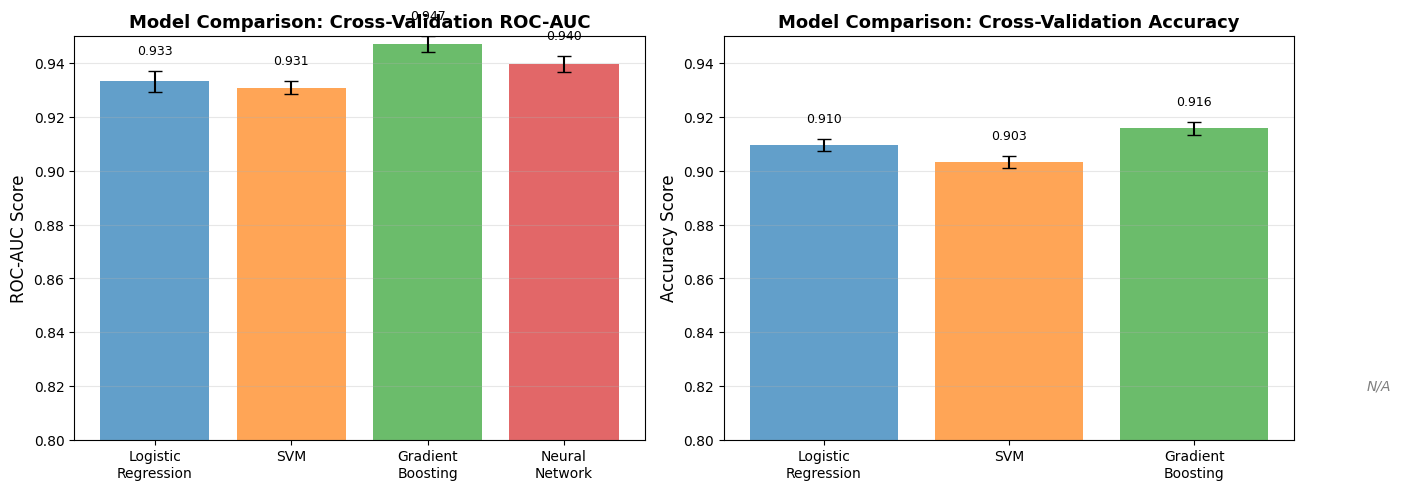


✓ Model comparison visualization saved to ../Data/model_comparison.png


In [40]:
import matplotlib.pyplot as plt
import numpy as np

# Create visualization of model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: ROC-AUC comparison
models = ['Logistic\nRegression', 'SVM', 'Gradient\nBoosting', 'Neural\nNetwork']

roc_auc_scores = [
    lr_cv_results['test_roc_auc'].mean(),
    svm_cv_results['test_roc_auc'].mean(),
    gb_cv_results['test_roc_auc'].mean(),
    best_nn_score
]

# Fixed: Get the std from the best NN result properly
nn_best_result = next(r for r in nn_results if r['mean_roc_auc'] == best_nn_score)

roc_auc_stds = [
    lr_cv_results['test_roc_auc'].std(),
    svm_cv_results['test_roc_auc'].std(),
    gb_cv_results['test_roc_auc'].std(),
    nn_best_result['std_roc_auc']  # Fixed: get std from the dict
]

axes[0].bar(models, roc_auc_scores, yerr=roc_auc_stds, capsize=5, alpha=0.7, 
            color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[0].set_ylabel('ROC-AUC Score', fontsize=12)
axes[0].set_title('Model Comparison: Cross-Validation ROC-AUC', fontsize=13, fontweight='bold')
axes[0].set_ylim([0.8, 0.95])
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (score, std) in enumerate(zip(roc_auc_scores, roc_auc_stds)):
    axes[0].text(i, score + std + 0.005, f'{score:.3f}', 
                ha='center', va='bottom', fontsize=9)

# Plot 2: Accuracy comparison
accuracy_scores = [
    lr_cv_results['test_accuracy'].mean(),
    svm_cv_results['test_accuracy'].mean(),
    gb_cv_results['test_accuracy'].mean(),
    np.nan  # NN doesn't have accuracy in cross-validation
]

accuracy_stds = [
    lr_cv_results['test_accuracy'].std(),
    svm_cv_results['test_accuracy'].std(),
    gb_cv_results['test_accuracy'].std(),
    0.0
]

# Only plot the first 3 bars (skip NN)
axes[1].bar(models[:3], accuracy_scores[:3], yerr=accuracy_stds[:3], 
            capsize=5, alpha=0.7, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1].set_ylabel('Accuracy Score', fontsize=12)
axes[1].set_title('Model Comparison: Cross-Validation Accuracy', fontsize=13, fontweight='bold')
axes[1].set_ylim([0.8, 0.95])
axes[1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (score, std) in enumerate(zip(accuracy_scores[:3], accuracy_stds[:3])):
    axes[1].text(i, score + std + 0.005, f'{score:.3f}', 
                ha='center', va='bottom', fontsize=9)

# Add note about missing NN data
axes[1].text(3, 0.82, 'N/A', ha='center', va='center', fontsize=10, 
            color='gray', style='italic')

plt.tight_layout()
plt.savefig('../Data/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Model comparison visualization saved to ../Data/model_comparison.png")